# RideWise Exploratory Data Analysis

### Using RideWise_cleaned_df.csv to explore and analyse the data

* Load the cleaned dataset
* Understand the trips patterns
* Generate distribution plots and correlations


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [125]:
df = pd.read_csv("../data/RideWise_cleaned_df.csv")

# To check the number of rows and columns
print("\n📌 Dataset Shape:", df.shape)

# Print the top 5 rows
df.head()


📌 Dataset Shape: (200000, 37)


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,trip_duration_mins,rider_age_group,pickup_hour,pickup_date,pickup_day,pickup_month,pickup_year,pickup_period,drop_off_day,drop_off_date
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50+00:00,2024-11-27 17:06:50+00:00,-1.108123,...,52,Established Adults,16,2024-11-27,Wednesday,November,2024,Evening,Wednesday,2024-11-27 00:00:00+00:00
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,13,Established Adults,22,2024-10-28,Monday,October,2024,Night,Monday,2024-10-28 00:00:00+00:00
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41+00:00,2025-02-17 03:25:41+00:00,-1.248589,...,16,Established Adults,3,2025-02-17,Monday,February,2025,Late Night,Monday,2025-02-17 00:00:00+00:00
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 17:22:14+00:00,2024-06-18 17:27:14+00:00,29.819554,...,5,Emerging Adults,17,2024-06-18,Tuesday,June,2024,Evening,Tuesday,2024-06-18 00:00:00+00:00
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 07:31:16+00:00,2024-10-05 08:01:16+00:00,-1.676479,...,30,Young Professionals,7,2024-10-05,Saturday,October,2024,Early Morning,Saturday,2024-10-05 00:00:00+00:00


In [126]:
# Print the bottom 5 rows
df.tail()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,trip_duration_mins,rider_age_group,pickup_hour,pickup_date,pickup_day,pickup_month,pickup_year,pickup_period,drop_off_day,drop_off_date
199995,T199995,R08022,D04562,26.79,1.3,0.0,Card,2025-03-14 18:02:26+00:00,2025-03-14 18:13:26+00:00,6.511389,...,11,Experienced Adults,18,2025-03-14,Friday,March,2025,Evening,Friday,2025-03-14 00:00:00+00:00
199996,T199996,R05421,D03984,14.65,1.0,0.0,Card,2024-07-02 06:45:36+00:00,2024-07-02 07:22:36+00:00,6.489143,...,37,Established Adults,6,2024-07-02,Tuesday,July,2024,Early Morning,Tuesday,2024-07-02 00:00:00+00:00
199997,T199997,R06619,D01173,12.87,1.2,0.0,Mobile Money,2024-05-06 20:24:57+00:00,2024-05-06 21:11:57+00:00,6.459348,...,47,Experienced Adults,20,2024-05-06,Monday,May,2024,Night,Monday,2024-05-06 00:00:00+00:00
199998,T199998,R02867,D00974,17.18,1.3,0.0,Mobile Money,2024-09-25 02:57:33+00:00,2024-09-25 03:31:33+00:00,6.540074,...,34,Emerging Adults,2,2024-09-25,Wednesday,September,2024,Late Night,Wednesday,2024-09-25 00:00:00+00:00
199999,T199999,R07749,D04894,13.47,1.0,0.0,Card,2024-05-24 16:14:39+00:00,2024-05-24 16:46:39+00:00,30.234277,...,32,Young Professionals,16,2024-05-24,Friday,May,2024,Evening,Friday,2024-05-24 00:00:00+00:00


## Dataset Overview

#### Basic information about data types & missing values

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   trip_id             200000 non-null  object 
 1   user_id             200000 non-null  object 
 2   driver_id           200000 non-null  object 
 3   fare                200000 non-null  float64
 4   surge_multiplier    200000 non-null  float64
 5   tip                 200000 non-null  float64
 6   payment_type        200000 non-null  object 
 7   pickup_time         200000 non-null  object 
 8   dropoff_time        200000 non-null  object 
 9   pickup_lat          200000 non-null  float64
 10  pickup_lng          200000 non-null  float64
 11  dropoff_lat         200000 non-null  float64
 12  dropoff_lng         200000 non-null  float64
 13  weather             200000 non-null  object 
 14  city                200000 non-null  object 
 15  loyalty_status      200000 non-nul

In [129]:
# Parse/convert dates datatypes

# Riders signup date 
if "rider_signup_date" in df.columns:
    df["rider_signup_date"] = pd.to_datetime(
        df["rider_signup_date"],
        errors="coerce",
        utc=True
    )

# Drivers signup date
if "driver_signup_date" in df.columns:
    df["driver_signup_date"] = pd.to_datetime(
        df["driver_signup_date"],
        errors="coerce",
        utc=True
    )

# Trips pickup & dropoff times 
for col in ["pickup_time", "dropoff_time", "pickup_date", "drop_off_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col],
            errors="coerce",
            utc=True
        )
# Drivers last active
df["last_active"] = pd.to_datetime(df["last_active"], errors="coerce", utc=True)

In [130]:
# To confirm the data types correction on the data info

df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   trip_id             200000 non-null  object             
 1   user_id             200000 non-null  object             
 2   driver_id           200000 non-null  object             
 3   fare                200000 non-null  float64            
 4   surge_multiplier    200000 non-null  float64            
 5   tip                 200000 non-null  float64            
 6   payment_type        200000 non-null  object             
 7   pickup_time         200000 non-null  datetime64[ns, UTC]
 8   dropoff_time        200000 non-null  datetime64[ns, UTC]
 9   pickup_lat          200000 non-null  float64            
 10  pickup_lng          200000 non-null  float64            
 11  dropoff_lat         200000 non-null  float64            
 12  dropoff_lng     

## Exploratory Data Analysis

### Univariate Analysis

city
Cairo      67436
Nairobi    66705
Lagos      65859
Name: count, dtype: int64


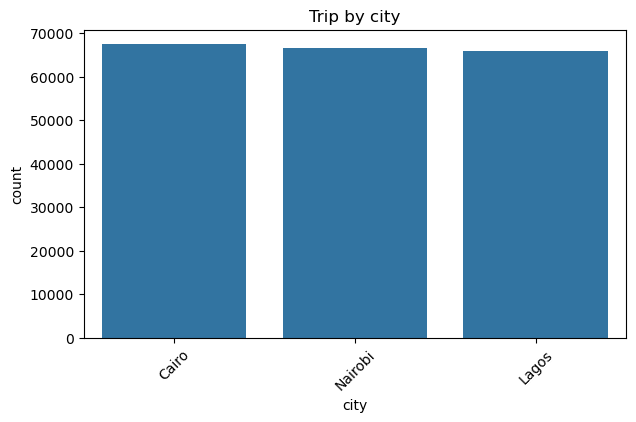

In [132]:
# Explore trip cities

print(df["city"].value_counts())

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="city", order=df["city"].value_counts().index)
plt.title("Trip by city")
plt.xticks(rotation=45)
plt.show()


**Insights:**
* Cairo has the highest trip volume, but only slightly ahead of Nairobi.
* The difference between all three cities is minimal (less than 1,600 trips between highest and lowest).
* Demand is fairly evenly distributed across the cities, indicating balanced market penetration.
* No city significantly dominates in trip activity, suggesting similar rider engagement levels.

vehicle_type
Sedan         97933
SUV           69791
Motorcycle    26188
Luxury         6088
Name: count, dtype: int64


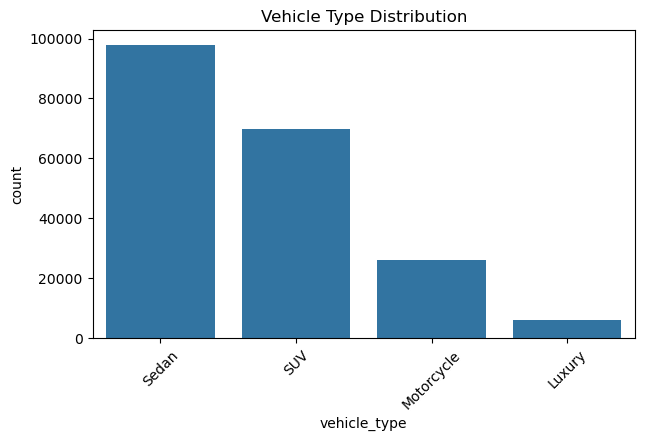

In [134]:
# Explore vehicle type

print(df["vehicle_type"].value_counts())

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="vehicle_type", order=df["vehicle_type"].value_counts().index)
plt.title("Vehicle Type Distribution")
plt.xticks(rotation=45)
plt.show()


**Insights:**
* Sedans dominate trip volume, accounting for the majority of rides.
* SUVs are the second most preferred option, but significantly lower than Sedans.
* Motorcycles serve a niche but meaningful segment, likely for shorter or cost-sensitive trips.
* Luxury vehicles have very low demand, indicating a small premium market segment.

weather
Sunny     120151
Rainy      39976
Cloudy     29874
Foggy       9999
Name: count, dtype: int64


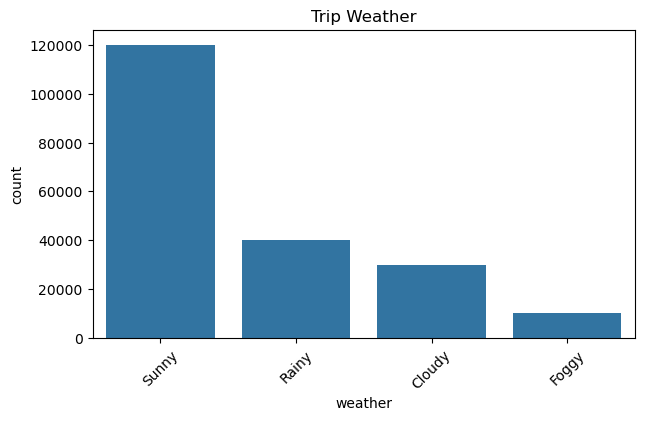

In [136]:
# Explore trip weather

print(df["weather"].value_counts())

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="weather", order=df["weather"].value_counts().index)
plt.title("Trip Weather")
plt.xticks(rotation=45)
plt.show()

**Insights:**
Trip demand is highly influenced by weather conditions, with sunny days driving the majority of platform activity. Adverse conditions such as fog significantly reduce trip volume, highlighting the impact of environmental factors on mobility patterns.

payment_type
Card            100326
Mobile Money     79661
Cash             20013
Name: count, dtype: int64


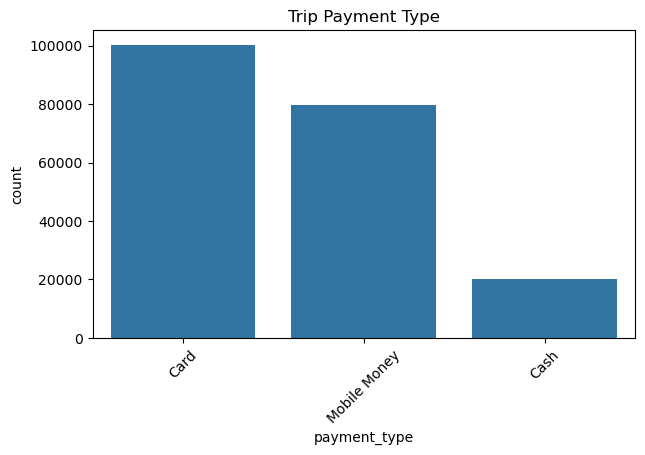

In [138]:
# Explore trip payment type

print(df["payment_type"].value_counts())

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="payment_type", order=df["payment_type"].value_counts().index)
plt.title("Trip Payment Type")
plt.xticks(rotation=45)
plt.show()

**Insights:**

* Over 90% of all trips are cashless.
* Card payments account for half of all transactions.
* Mobile Money represents a strong secondary payment channel.
* Cash is used in only about 1 in 10 trips, showing strong digital adoption.

rider_age_group
Established Adults     69437
Young Professionals    68285
Emerging Adults        31565
Experienced Adults     26340
Mature Adults           4373
Name: count, dtype: int64


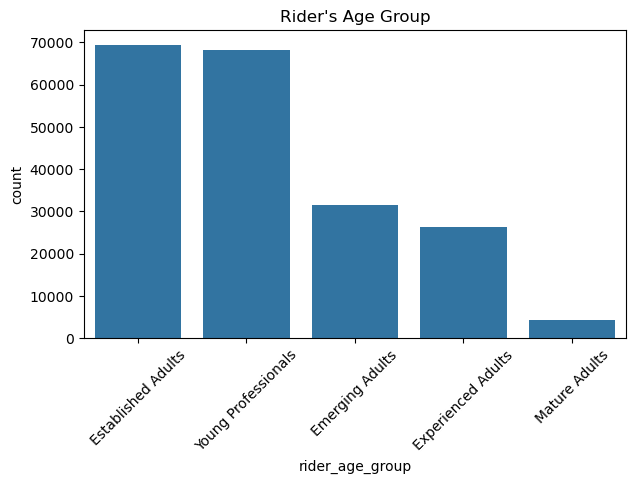

In [140]:
# Explore Rider's Age Group

print(df["rider_age_group"].value_counts())

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="rider_age_group", order=df["rider_age_group"].value_counts().index)
plt.title("Rider's Age Group")
plt.xticks(rotation=45)
plt.show()

**Insights:**

Trip activity is heavily concentrated among riders aged 26–45 (Established adults and young professionals), who account for nearly 70% of total rides. This highlights the platform’s strong penetration within the economically active population, while older age groups represent a smaller share of overall mobility demand.

loyalty_status
Bronze      121252
Silver       48332
Gold         21044
Platinum      9372
Name: count, dtype: int64


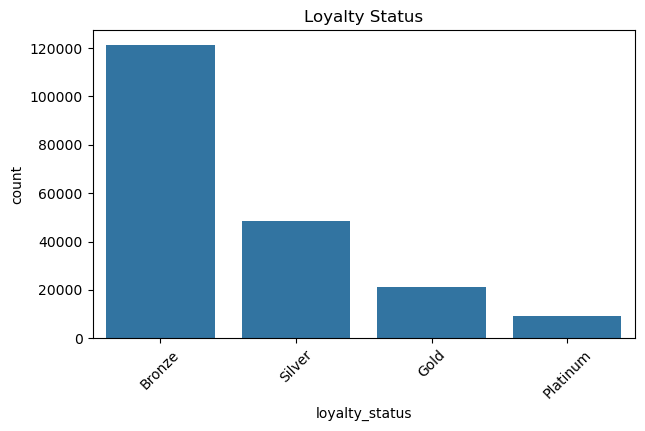

In [142]:
# Explore loyalty status 

print(df["loyalty_status"].value_counts())

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="loyalty_status", order=df["loyalty_status"].value_counts().index)
plt.title("Loyalty Status")
plt.xticks(rotation=45)
plt.show()

**Insights:**

The rider base is heavily concentrated in the Bronze tier (61%), with relatively few users progressing to higher loyalty levels. Strengthening loyalty conversion strategies could significantly increase rider retention and long-term revenue growth.

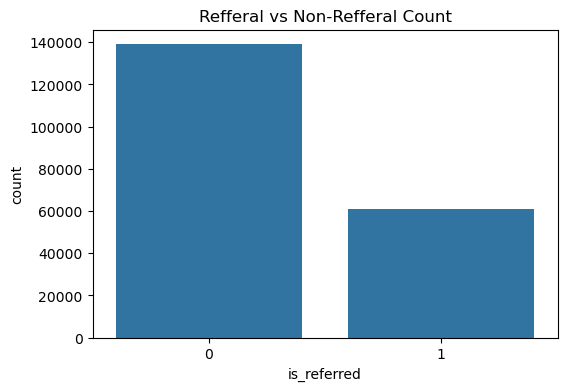

Refferal Rate: 30.51 %


In [144]:
# Refferal Distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="is_referred")
plt.title("Refferal vs Non-Refferal Count")
plt.show()

refferal_rate = df["is_referred"].mean()
print("Refferal Rate:", round(refferal_rate*100, 2), "%")

**Insights:**

With a 30.51% referral rate, the platform demonstrates strong organic growth driven by user advocacy. Continued investment in referral incentives could further accelerate customer acquisition and retention.

### Numeric Column Distributions

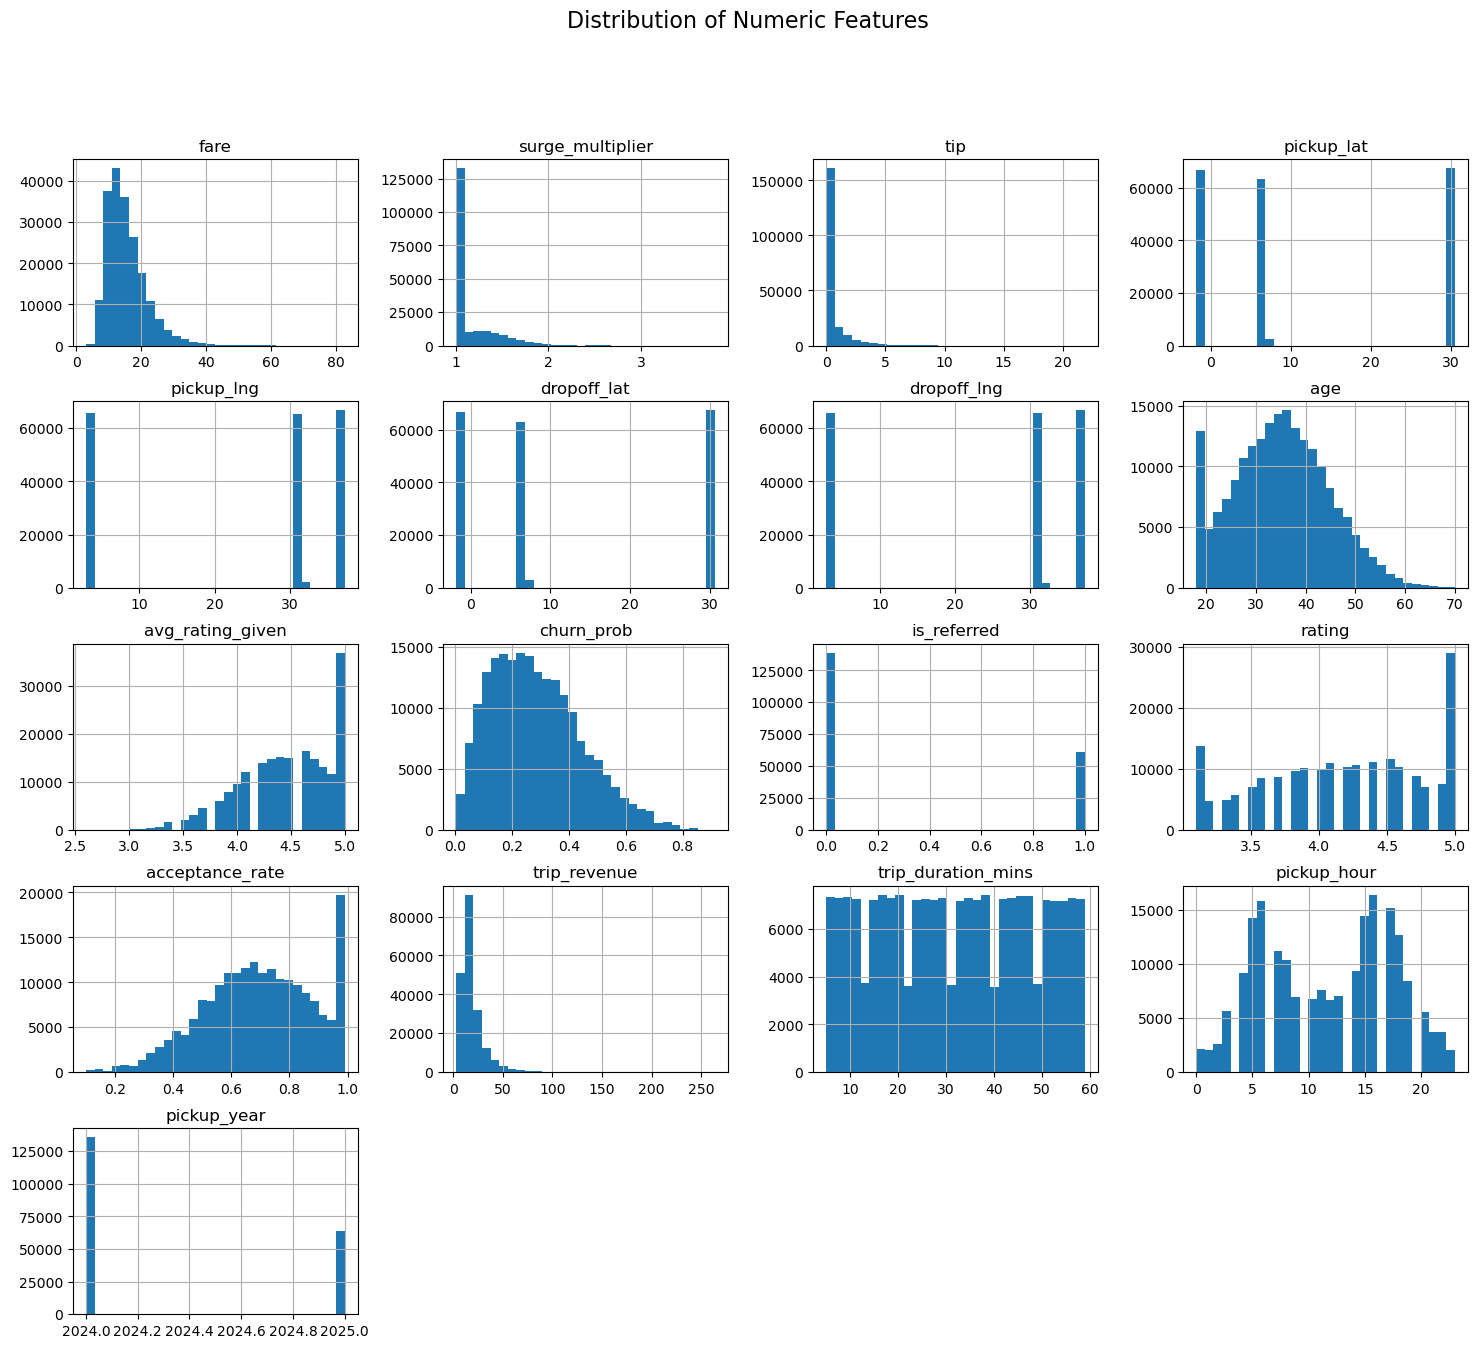

In [147]:
# Explore numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(bins=30, figsize=(18,15))
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

### Bivariate Analysis

Trips by Day of Week:

pickup_day
Monday       28457
Tuesday      28567
Wednesday    28379
Thursday     28315
Friday       28539
Saturday     28731
Sunday       29012
Name: count, dtype: int64


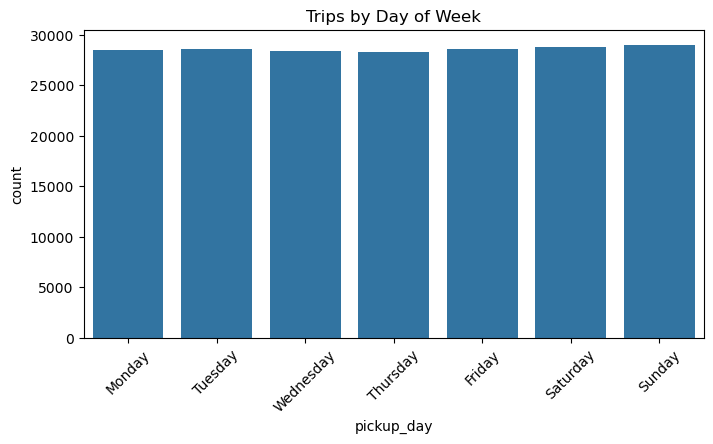

In [149]:
# Trips by day of week

day_counts = df["pickup_day"].value_counts().reindex(weekday_order)
print("Trips by Day of Week:\n")
print(day_counts)

# Plot
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="pickup_day", order=weekday_order)
plt.title("Trips by Day of Week")
plt.xticks(rotation=45)
plt.show()

**Insights:**

Trip demand remains consistently high across all days of the week, with a slight increase during weekends. The evenly distributed activity suggests stable user reliance on the platform for both work-related and leisure travel.

Average Fare by Weather:

         avg_fare
weather          
Rainy       19.04
Sunny       14.50
Foggy       14.48
Cloudy      14.47


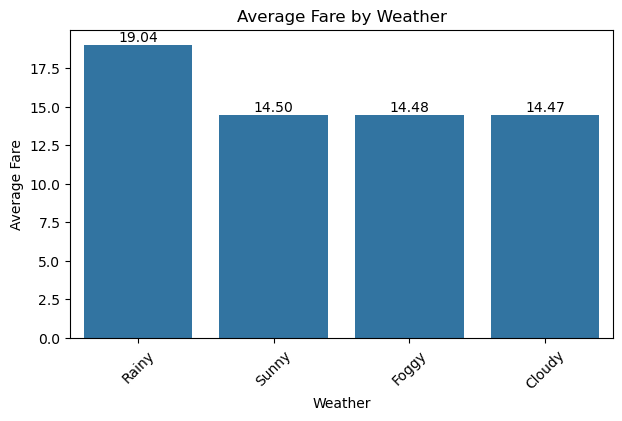

In [151]:
# Calculate average fare by weather 

weather_avg_fare = (
    df.groupby("weather")
      .agg(avg_fare=("fare", "mean"))
      .sort_values(by="avg_fare", ascending=False)
)

print("Average Fare by Weather:\n")
print(weather_avg_fare.round(2))

# To visualize 

plt.figure(figsize=(7,4))

ax = sns.barplot(
    x=weather_avg_fare.index,
    y=weather_avg_fare["avg_fare"]
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Fare by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Fare")
plt.xticks(rotation=45)

plt.show()

**Insights:**

Rain significantly increases average fare levels, suggesting strong demand pressure and potential surge pricing during adverse weather. In contrast, fares remain stable across sunny, cloudy, and foggy conditions, indicating consistent baseline pricing.

Revenue by Rider's Age Group:

                     total_revenue  avg_revenue_per_trip  total_trips
rider_age_group                                                      
Emerging Adults          594869.13                 18.85        31565
Established Adults      1320254.72                 19.01        69437
Experienced Adults       496322.17                 18.84        26340
Mature Adults             82294.53                 18.82         4373
Young Professionals     1291769.62                 18.92        68285


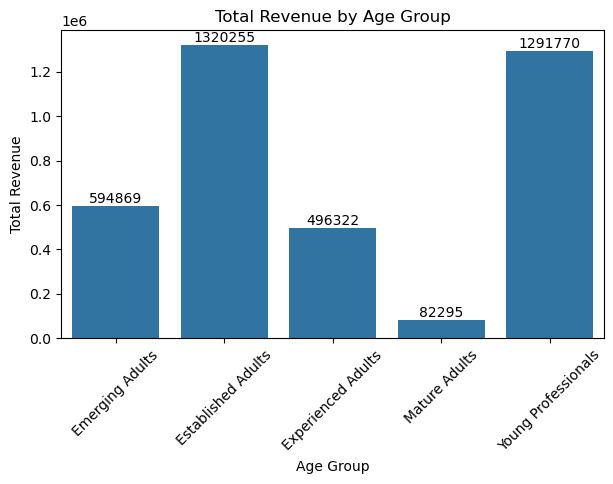

In [153]:
# Revenue by rider age group

age_revenue_summary = (
    df.groupby("rider_age_group")
      .agg(
          total_revenue=("trip_revenue", "sum"),
          avg_revenue_per_trip=("trip_revenue", "mean"),
          total_trips=("trip_id", "count")
      )
      .sort_index()
)

print("Revenue by Rider's Age Group:\n")
print(age_revenue_summary.round(2))


# Visualize the top revenue generated by different age groups
plt.figure(figsize=(7,4))

ax = sns.barplot(
    x=age_revenue_summary.index,
    y=age_revenue_summary["total_revenue"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Total Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

**Insights:**

* Established Adults (36–45) generate the highest total revenue (~1.32M).
* Young Professionals (26–35) closely follow (~1.29M).
* Revenue generation is strongly concentrated among riders aged 26–45, who account for the majority of total trips and revenue. Average revenue per trip remains consistent across all age groups, indicating that revenue growth is primarily driven by trip frequency rather than price differentiation

Revenue by City:

         total_revenue  avg_revenue_per_trip  total_trips
city                                                     
Cairo       1271300.52                 18.85        67436
Lagos       1264027.69                 19.19        65859
Nairobi     1250181.96                 18.74        66705


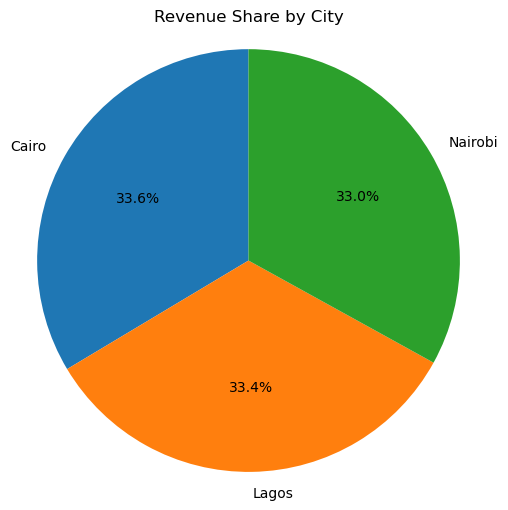

In [155]:
# Aggregate revenue by city 

city_revenue_summary = (
    df.groupby("city")
      .agg(
          total_revenue=("trip_revenue", "sum"),
          avg_revenue_per_trip=("trip_revenue", "mean"),
          total_trips=("trip_id", "count")
      )
      .sort_values(by="total_revenue", ascending=False)
)

print("Revenue by City:\n")
print(city_revenue_summary.round(2))


# Visualization
plt.figure(figsize=(6,6))

plt.pie(
    city_revenue_summary["total_revenue"],
    labels=city_revenue_summary.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by City")
plt.axis("equal")  

plt.show()

**Insights:**

Revenue performance is evenly distributed across Cairo, Lagos, and Nairobi, indicating balanced market strength. Lagos stands out with the highest average revenue per trip, while Cairo leads slightly in total revenue due to higher trip volume.

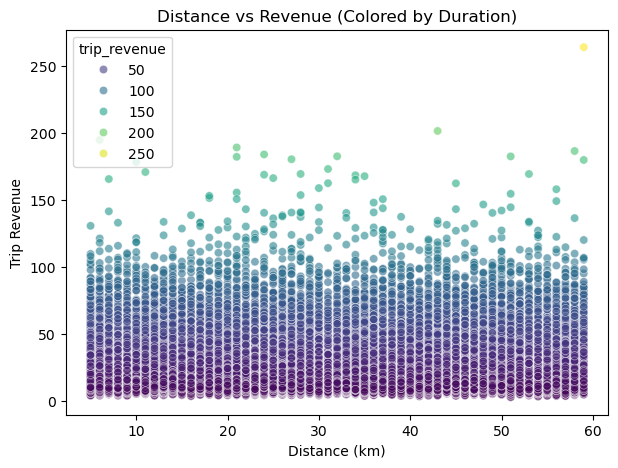

In [157]:
# TRIP FARE BY DISTANCE

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="trip_duration_mins",
    y="trip_revenue",
    hue="trip_revenue",
    palette="viridis",
    alpha=0.6
)

plt.title("Distance vs Revenue (Colored by Duration)")
plt.xlabel("Distance (km)")
plt.ylabel("Trip Revenue")

plt.show()

**Insights:**

The results indicate that trip distance does not significantly influence fare amount.

Revenue by Period of Day:

               total_revenue  avg_revenue  total_trips
pickup_period                                         
Afternoon          688979.95        18.28        37692
Early Morning     1040358.28        20.60        50495
Evening           1038379.06        19.69        52726
Late Night         205135.57        16.50        12429
Morning            564307.03        17.84        31640
Night              248350.26        16.54        15018


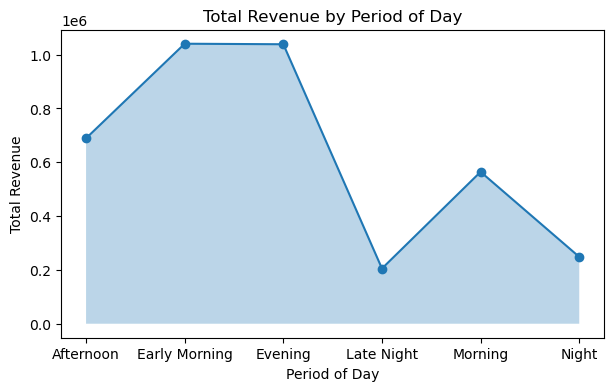

In [159]:
period_revenue = (
    df.groupby("pickup_period")
      .agg(
          total_revenue=("trip_revenue", "sum"),
          avg_revenue=("trip_revenue", "mean"),
          total_trips=("trip_id", "count")
      )
      
)

print("Revenue by Period of Day:\n")
print(period_revenue.round(2))

plt.figure(figsize=(7,4))

# X values (categorical index converted to range positions)
x = range(len(period_revenue.index))
y = period_revenue["total_revenue"]

# Plot line
plt.plot(x, y, marker="o")

# Fill area under the curve
plt.fill_between(x, y, alpha=0.3)

# Replace numeric x-axis with labels
plt.xticks(x, period_revenue.index)

plt.title("Total Revenue by Period of Day")
plt.xlabel("Period of Day")
plt.ylabel("Total Revenue")

# Remove grid
plt.grid(False)

plt.show()

**Insights:**

* Peak commute periods (Early Morning & Evening) are the primary revenue drivers.
* Higher average fares during Early Morning indicate potential surge pricing effectiveness.
* Night segments may require:
    * Incentives to increase driver availability
    * Targeted promotions to boost demand

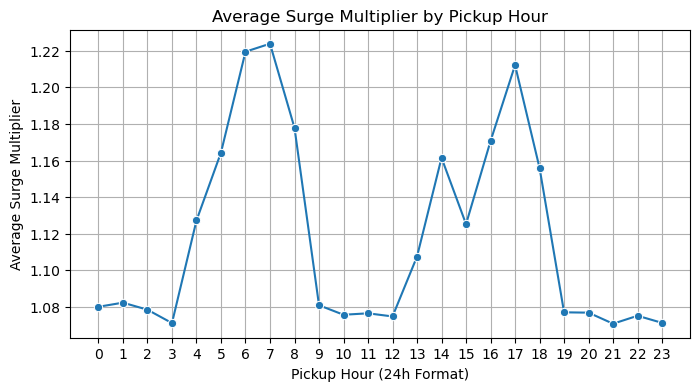

In [161]:
# AVERAGE SURGE BY TRIP DEPARTURE TIME

# Create pickup hour 
df["pickup_hour"] = df["pickup_time"].dt.hour

# Aggregate average surge by hour 
surge_hour_summary = (
    df.groupby("pickup_hour")
      .agg(
          avg_surge=("surge_multiplier", "mean"),
          total_trips=("trip_id", "count")
      )
      .sort_index()
)

plt.figure(figsize=(8,4))

ax = sns.lineplot(
    x=surge_hour_summary.index,
    y=surge_hour_summary["avg_surge"],
    marker="o"
)

plt.title("Average Surge Multiplier by Pickup Hour")
plt.xlabel("Pickup Hour (24h Format)")
plt.ylabel("Average Surge Multiplier")
plt.xticks(range(0,24))
plt.grid(True)

plt.show()

**Insights:**

Elevated surge multipliers during peak periods, particularly Early Morning and Evening are directly contributing to higher average fares and increased total revenue. This confirms that dynamic pricing is effectively aligned with demand intensity.

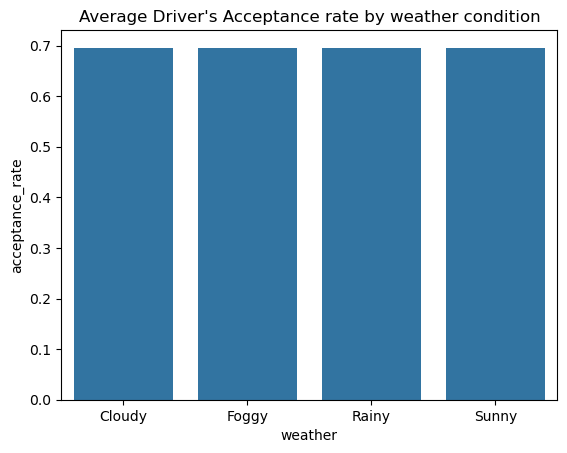

In [163]:
# Average Driver's Acceptance rate by weather condition

Weather_Acpt = df.groupby("weather")["acceptance_rate"].mean().reset_index()
sns.barplot(x='weather', data=Weather_Acpt, y='acceptance_rate')
plt.title("Average Driver's Acceptance rate by weather condition");

**Insights:**

Driver acceptance rates remain stable across different weather conditions, suggesting resilient driver participation and effective pricing mechanisms that maintain supply regardless of environmental factors.

### Multivariate Analysis


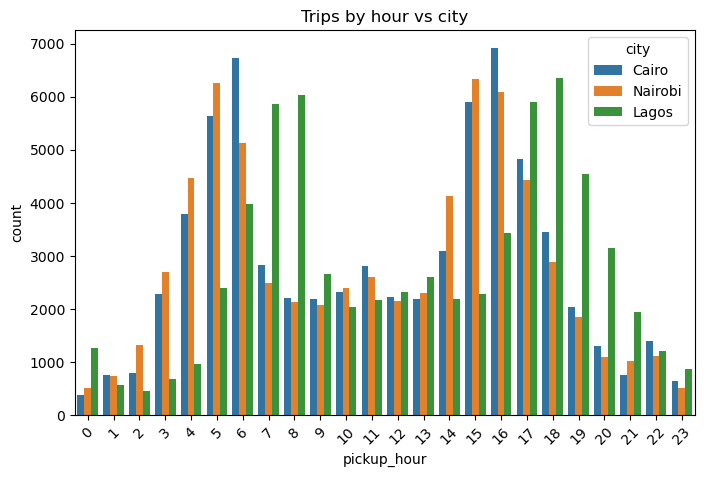

In [166]:
# Trips by hour vs city

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="pickup_hour", hue="city")
plt.title("Trips by hour vs city")
plt.xticks(rotation=45)
plt.show()

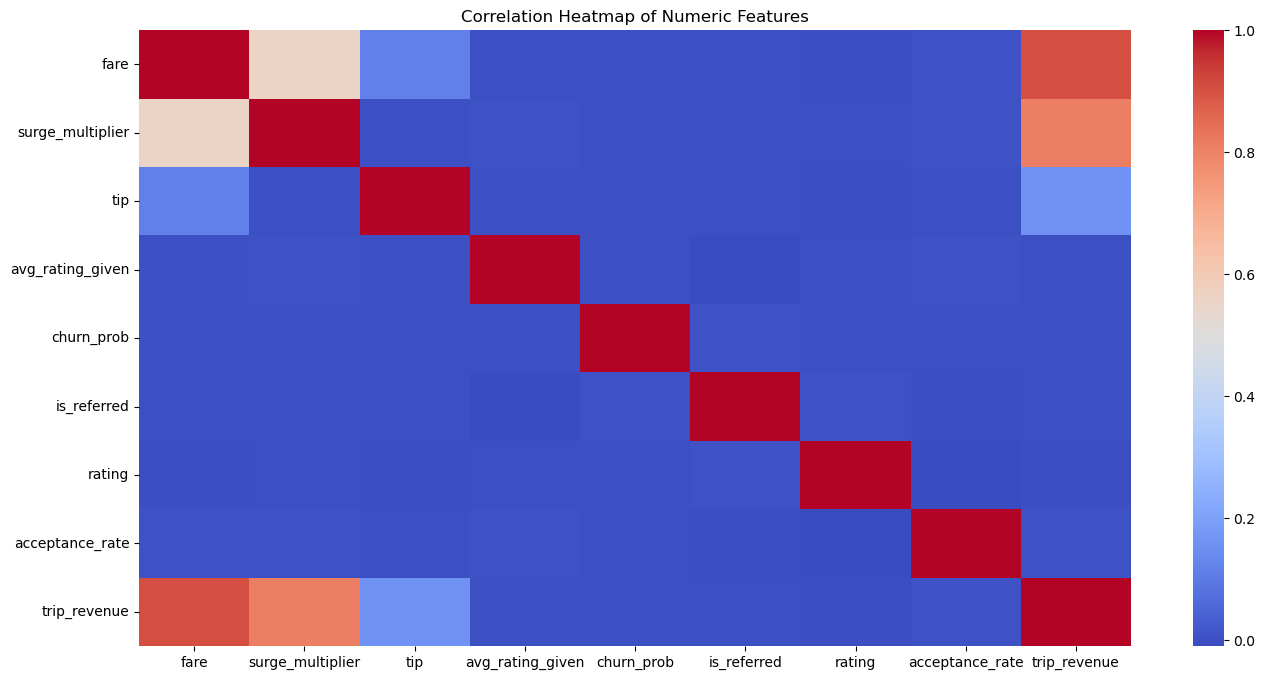

In [167]:
# Examine the correlation between the numerical columns

plt.figure(figsize=(16,8))
sns.heatmap(df[['fare', 'surge_multiplier', 'tip', 'avg_rating_given', 'churn_prob', 'is_referred', 'rating', 'acceptance_rate', 'trip_revenue']].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Save the Dataset

In [216]:
EDA_df = df.copy()

EDA_df.to_csv(r"C:\Users\pehlu\OneDrive\projects\RideWise\Data\RideWise_EDA_df.csv", index=False)

print('The dataframe was saved successfully')

The dataframe was saved successfully
